<a href="https://colab.research.google.com/github/davidogm/DataScience/blob/main/ITBD/notebooks/spark/ITBD_W3_S3_Spark_Practica_Progresiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITBD — Semana 3
## Práctica progresiva: S3 → Spark

**Recorrido:** leer → explorar → filtrar → transformar → agrupar → agregar → acción.

Objetivos: trabajar con un Spark DataFrame leído directamente desde S3, distinguir transformaciones/acciones, observar particiones y *lazy evaluation*, localizar el *shuffle* y comparar el flujo con pandas.

> Punto de partida: la configuración S3A del segundo notebook ya funciona y existe una `SparkSession` llamada `spark` con acceso a `s3a://davidgil/trips.csv`.

## 0. Preparación del entorno

Este notebook es **autocontenido**: aunque la configuración se explica con detalle en el notebook 04, aquí repetimos únicamente las celdas imprescindibles para iniciar una nueva sesión de Colab.

> Si acabas de reiniciar Colab, ejecuta este bloque completo antes de comenzar la práctica.

### 0.1 Instalar PySpark y boto3, y descargar las dependencias S3A

In [13]:
!pip -q install boto3 pyspark

!wget -q https://repo1.maven.org/maven2/org/apache/hadoop/hadoop-aws/3.4.1/hadoop-aws-3.4.1.jar
!wget -q https://repo1.maven.org/maven2/software/amazon/awssdk/bundle/2.24.6/bundle-2.24.6.jar

print("✅ Dependencias preparadas")

✅ Dependencias preparadas


### 0.2 Introducir las credenciales temporales del AWS Lab

Introduce **Access Key**, **Secret Key** y **Session Token**. `getpass` evita que los valores aparezcan escritos en pantalla.

Las credenciales son temporales: si el Lab se apaga o reinicia, puede ser necesario volver a obtenerlas.

In [14]:
import os
import getpass

os.environ["AWS_ACCESS_KEY_ID"] = getpass.getpass("AWS_ACCESS_KEY_ID: ")
os.environ["AWS_SECRET_ACCESS_KEY"] = getpass.getpass("AWS_SECRET_ACCESS_KEY: ")
os.environ["AWS_SESSION_TOKEN"] = getpass.getpass("AWS_SESSION_TOKEN: ")

print("✅ Credenciales cargadas en esta sesión")

AWS_ACCESS_KEY_ID: ··········
AWS_SECRET_ACCESS_KEY: ··········
AWS_SESSION_TOKEN: ··········
✅ Credenciales cargadas en esta sesión


### 0.3 Crear la SparkSession con soporte S3A

In [15]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ITBD-W3-Practica")
    .master("local[*]")
    .config(
        "spark.jars",
        "/content/hadoop-aws-3.4.1.jar,/content/bundle-2.24.6.jar"
    )
    .getOrCreate()
)

print("Spark:", spark.version)

jvm = spark.sparkContext._jvm
print("Hadoop:", jvm.org.apache.hadoop.util.VersionInfo.getVersion())

Spark: 4.0.4
Hadoop: 3.4.1


### 0.4 Configurar las credenciales temporales para Hadoop S3A

In [16]:
hadoop_conf = spark.sparkContext._jsc.hadoopConfiguration()

hadoop_conf.set("fs.s3a.access.key", os.environ["AWS_ACCESS_KEY_ID"])
hadoop_conf.set("fs.s3a.secret.key", os.environ["AWS_SECRET_ACCESS_KEY"])
hadoop_conf.set("fs.s3a.session.token", os.environ["AWS_SESSION_TOKEN"])
hadoop_conf.set(
    "fs.s3a.aws.credentials.provider",
    "org.apache.hadoop.fs.s3a.TemporaryAWSCredentialsProvider"
)

print("✅ Spark + S3A preparados")

✅ Spark + S3A preparados


### 0.5 Comprobación rápida

Antes de empezar la práctica comprobamos que Hadoop reconoce S3A. La explicación completa y el diagnóstico de errores están en el notebook 04.

In [17]:
uri = spark.sparkContext._jvm.java.net.URI("s3a://davidgil")
fs = spark.sparkContext._jvm.org.apache.hadoop.fs.FileSystem.get(uri, hadoop_conf)

print("✅ S3A disponible")
print("FileSystem:", fs.getClass().getName())

✅ S3A disponible
FileSystem: org.apache.hadoop.fs.s3a.S3AFileSystem


## 1. LEER
Spark accede al objeto mediante Hadoop S3A. La URI nativa es `s3://davidgil/trips.csv`; desde Spark usamos `s3a://davidgil/trips.csv`.

In [18]:
s3_path = "s3a://davidgil/trips.csv"

trips = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(s3_path)
)

print(type(trips))

<class 'pyspark.sql.classic.dataframe.DataFrame'>


### pandas frente a Spark
```python
# pandas
df = pd.read_csv("trips.csv")

# Spark
df = spark.read.option("header", True).option("inferSchema", True).csv(s3_path)
```
Spark trabaja con particiones y un plan de ejecución que puede trasladarse a un clúster.

## 2. EXPLORAR
Primero observamos filas, columnas, esquema y particiones.

In [19]:
trips.show(5, truncate=False)
print("Columnas:", len(trips.columns))
print(trips.columns)
trips.printSchema()
print("Particiones:", trips.rdd.getNumPartitions())

+---+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-------------+-------------+
|_c0|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee19|airport_fee20|
+---+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-------------+-------------+
|0  |2       |2023-06-30 23:59:59 |2023-07-01 00:47:49  |2.0            |17.62        |2.0       |N                 |132       

### Primera acción: `count()`
`count()` necesita un resultado real y por ello es una **acción**: obliga a Spark a ejecutar el trabajo necesario.

In [20]:
n = trips.count()
print(f"Número de viajes: {n:,}")

Número de viajes: 1,000


## 3. FILTRAR
Nos quedamos con viajes con distancia positiva, tarifa no negativa y zona de origen conocida. `filter()` es una **transformación**: produce un nuevo DataFrame sin modificar el anterior.

Un filtro puede aplicarse localmente sobre cada partición; por sí solo no exige reunir filas con la misma clave.

In [21]:
from pyspark.sql import functions as F

trips_validos = trips.filter(
    (F.col("trip_distance") > 0) &
    (F.col("fare_amount") >= 0) &
    F.col("PULocationID").isNotNull()
)

print("Transformación definida.")

Transformación definida.


## 4. TRANSFORMAR
Creamos `pickup_hour`, `trip_minutes` y `fare_per_mile`. `withColumn()` también es una transformación.

In [22]:
trips_enriquecidos = (
    trips_validos
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn("trip_minutes",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60.0)
    .withColumn("fare_per_mile",
        F.when(F.col("trip_distance") > 0, F.col("fare_amount") / F.col("trip_distance")))
)

trips_enriquecidos.select(
    "tpep_pickup_datetime","trip_distance","fare_amount",
    "pickup_hour","trip_minutes","fare_per_mile"
).show(5)

+--------------------+-------------+-----------+-----------+------------------+------------------+
|tpep_pickup_datetime|trip_distance|fare_amount|pickup_hour|      trip_minutes|     fare_per_mile|
+--------------------+-------------+-----------+-----------+------------------+------------------+
| 2023-06-30 23:59:59|        17.62|       70.0|         23|47.833333333333336|3.9727582292849033|
| 2023-06-30 23:59:57|         3.32|       18.4|         23|             17.65| 5.542168674698795|
| 2023-06-30 23:59:55|          2.8|       14.9|         23|14.416666666666666| 5.321428571428572|
| 2023-06-30 23:59:55|         0.89|        7.2|         23|              5.95| 8.089887640449438|
| 2023-06-30 23:59:55|         1.56|       10.0|         23| 7.216666666666667|  6.41025641025641|
+--------------------+-------------+-----------+-----------+------------------+------------------+
only showing top 5 rows


`show()` es una **acción**. Spark puede encadenar varias transformaciones y retrasar su ejecución hasta que una acción solicita un resultado: esto es *lazy evaluation*.

## 5. AGRUPAR — aparece el shuffle
Pregunta: **¿cómo cambia la movilidad según la hora?**

Para agregar por `pickup_hour`, filas de distintas particiones con la misma hora deben reunirse. Esa redistribución es un **shuffle**.

```text
P1: 8h 9h 8h ─┐
P2: 10h 8h 9h ├─► redistribución por clave ─► 8h | 9h | 10h
P3: 9h 10h 8h ┘
```

In [23]:
por_hora = trips_enriquecidos.groupBy("pickup_hour")
print(type(por_hora))

<class 'pyspark.sql.group.GroupedData'>


## 6. AGREGAR
Calculamos número de viajes, distancia media, tarifa media y duración media por hora.

In [24]:
resumen_hora = (
    trips_enriquecidos
    .groupBy("pickup_hour")
    .agg(
        F.count("*").alias("num_trips"),
        F.avg("trip_distance").alias("avg_distance"),
        F.avg("fare_amount").alias("avg_fare"),
        F.avg("trip_minutes").alias("avg_minutes")
    )
    .orderBy("pickup_hour")
)

print("Plan definido; todavía no hemos pedido el resultado final.")

Plan definido; todavía no hemos pedido el resultado final.


## 7. Ver el plan y localizar el shuffle
`explain()` permite inspeccionar el plan. No hace falta entender cada detalle. Busca **`Exchange`** en el plan. Spark utiliza este operador cuando necesita redistribuir datos entre particiones. Esa redistribución es lo que llamamos **shuffle**.

Modelo mental:
```text
LEER → FILTRAR → TRANSFORMAR → AGRUPAR → SHUFFLE → AGREGAR → ORDENAR → RESULTADO
```

In [25]:
resumen_hora.explain(mode="simple")

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [pickup_hour#170 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(pickup_hour#170 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=102]
      +- HashAggregate(keys=[pickup_hour#170], functions=[count(1), avg(trip_distance#22), avg(fare_amount#28), avg(trip_minutes#171)])
         +- Exchange hashpartitioning(pickup_hour#170, 200), ENSURE_REQUIREMENTS, [plan_id=99]
            +- HashAggregate(keys=[pickup_hour#170], functions=[partial_count(1), partial_avg(trip_distance#22), partial_avg(fare_amount#28), partial_avg(trip_minutes#171)])
               +- Project [trip_distance#22, fare_amount#28, hour(tpep_pickup_datetime#19, Some(Etc/UTC)) AS pickup_hour#170, (cast((unix_timestamp(tpep_dropoff_datetime#20, yyyy-MM-dd HH:mm:ss, Some(Etc/UTC), true) - unix_timestamp(tpep_pickup_datetime#19, yyyy-MM-dd HH:mm:ss, Some(Etc/UTC), true)) as double) / 60.0) AS trip_minutes#171]
                  +- Filter ((((isnotnul

## 8. ACCIÓN
Ahora pedimos el resultado. `show()` dispara la ejecución necesaria.

In [26]:
resumen_hora.show(24, truncate=False)

+-----------+---------+-----------------+-----------------+-----------------+
|pickup_hour|num_trips|avg_distance     |avg_fare         |avg_minutes      |
+-----------+---------+-----------------+-----------------+-----------------+
|23         |981      |4.439306829765548|21.58968399592253|15.67847434590553|
+-----------+---------+-----------------+-----------------+-----------------+



### `collect()` y el Driver
`collect()` ejecuta el plan y trae **todas las filas del resultado final al Driver**. Es razonable para un resultado pequeño, como 24 horas, pero no para millones de filas.

In [27]:
resultado_driver = resumen_hora.collect()
print("Filas en el Driver:", len(resultado_driver))
print(resultado_driver[:3])

Filas en el Driver: 1
[Row(pickup_hour=23, num_trips=981, avg_distance=4.439306829765548, avg_fare=21.58968399592253, avg_minutes=15.67847434590553)]


> `collect()` no hace que Spark sea distribuido. Es una acción que solicita el resultado y lo lleva al Driver.

## 9. Spark → pandas cuando el resultado ya es pequeño
Una vez reducido el dataset a pocas filas agregadas, podemos convertirlo a pandas para visualizar.

In [28]:
resumen_pd = resumen_hora.toPandas()
resumen_pd.head()

,pickup_hour,num_trips,avg_distance,avg_fare,avg_minutes
0,23,981,4.439307,21.589684,15.678474


In [34]:
top_zonas = (
    trips_enriquecidos
    .groupBy("PULocationID")
    .agg(
        F.count("*").alias("num_trips"),
        F.avg("trip_distance").alias("avg_distance"),
        F.avg("fare_amount").alias("avg_fare")
    )
    .orderBy(F.desc("num_trips"))
    .limit(10)
)

top_zonas.show()

+------------+---------+------------------+------------------+
|PULocationID|num_trips|      avg_distance|          avg_fare|
+------------+---------+------------------+------------------+
|         132|       74|16.926216216216215| 62.54459459459461|
|         138|       67| 9.852238805970146|41.938805970149254|
|         249|       59|2.3418644067796612|14.076271186440684|
|          79|       50|            2.5006|            14.536|
|          48|       49|2.9585714285714304| 15.56061224489796|
|         114|       39| 3.036923076923077|19.146153846153847|
|         230|       33| 3.458787878787878|18.951515151515153|
|         148|       28|3.4514285714285715|18.977499999999996|
|         234|       27| 3.308888888888889|17.672962962962963|
|         164|       26|1.9019230769230768|12.503846153846155|
+------------+---------+------------------+------------------+



In [35]:
top_zonas.explain(mode="simple")

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=10, orderBy=[num_trips#383L DESC NULLS LAST], output=[PULocationID#25,num_trips#383L,avg_distance#384,avg_fare#385])
   +- HashAggregate(keys=[PULocationID#25], functions=[count(1), avg(trip_distance#22), avg(fare_amount#28)])
      +- Exchange hashpartitioning(PULocationID#25, 200), ENSURE_REQUIREMENTS, [plan_id=369]
         +- HashAggregate(keys=[PULocationID#25], functions=[partial_count(1), partial_avg(trip_distance#22), partial_avg(fare_amount#28)])
            +- Filter ((((isnotnull(trip_distance#22) AND isnotnull(fare_amount#28)) AND (trip_distance#22 > 0.0)) AND (fare_amount#28 >= 0.0)) AND isnotnull(PULocationID#25))
               +- FileScan csv [trip_distance#22,PULocationID#25,fare_amount#28] Batched: false, DataFilters: [isnotnull(trip_distance#22), isnotnull(fare_amount#28), (trip_distance#22 > 0.0), (fare_amount#2..., Format: CSV, Location: InMemoryFileIndex(1 paths)[s3a://davidgil/

In [36]:
top_zonas_pd = top_zonas.toPandas()

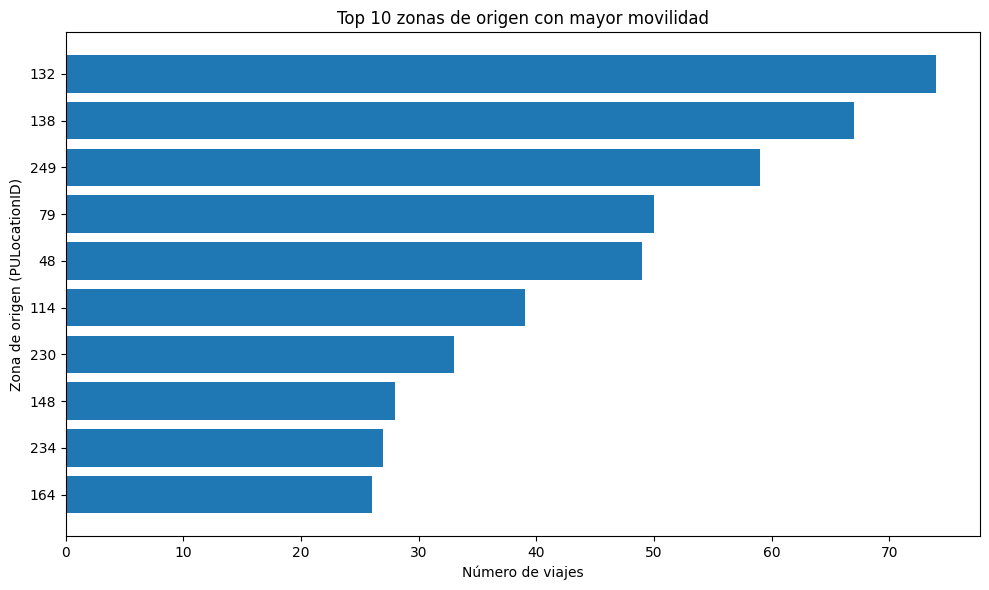

In [37]:
import matplotlib.pyplot as plt

top_zonas_pd = top_zonas_pd.sort_values("num_trips")

plt.figure(figsize=(10, 6))

plt.barh(
    top_zonas_pd["PULocationID"].astype(str),
    top_zonas_pd["num_trips"]
)

plt.xlabel("Número de viajes")
plt.ylabel("Zona de origen (PULocationID)")
plt.title("Top 10 zonas de origen con mayor movilidad")

plt.tight_layout()
plt.show()

## 10. Equivalencias pandas / PySpark

| Etapa | pandas | PySpark |
|---|---|---|
| Leer | `pd.read_csv()` | `spark.read.csv()` |
| Explorar | `head()`, `info()` | `show()`, `printSchema()` |
| Filtrar | `df[condición]` | `filter()` |
| Transformar | asignación / `assign()` | `withColumn()` |
| Agrupar | `groupby()` | `groupBy()` |
| Agregar | `agg()` | `agg()` |
| Obtener resultado | normalmente inmediato | acción: `show`, `count`, `collect`... |

La cuestión no es solo sintáctica: Spark introduce particiones, planificación *lazy* y redistribución de datos.

## 11. La misma lógica con pandas
Para comparar el modelo de programación, podemos leer el mismo objeto con boto3 y pandas. El fichero de la práctica es pequeño; **no buscamos demostrar que Spark sea más rápido en este caso**.

In [30]:
import boto3
import pandas as pd
from io import BytesIO

s3_client = boto3.client("s3")
obj = s3_client.get_object(Bucket="davidgil", Key="trips.csv")
trips_pd = pd.read_csv(BytesIO(obj["Body"].read()))
trips_pd.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,0,2,2023-06-30 23:59:59,2023-07-01 00:47:49,2.0,17.62,2.0,N,132,230,...,70.0,0.0,0.5,0.00,6.55,1.0,82.30,2.5,1.75,NaN
1,1,2,2023-06-30 23:59:57,2023-07-01 00:17:36,1.0,3.32,1.0,N,255,198,...,18.4,1.0,0.5,2.50,0.00,1.0,23.40,0.0,0.00,NaN
2,2,1,2023-06-30 23:59:55,2023-07-01 00:14:20,1.0,2.80,1.0,N,231,107,...,14.9,3.5,0.5,3.95,0.00,1.0,23.85,2.5,0.00,NaN
3,3,2,2023-06-30 23:59:55,2023-07-01 00:05:52,1.0,0.89,1.0,N,237,163,...,7.2,1.0,0.5,2.00,0.00,1.0,14.20,2.5,0.00,NaN
4,4,2,2023-06-30 23:59:55,2023-07-01 00:07:08,4.0,1.56,1.0,N,211,90,...,10.0,1.0,0.5,3.00,0.00,1.0,18.00,2.5,0.00,NaN


In [31]:
trips_pd["tpep_pickup_datetime"] = pd.to_datetime(trips_pd["tpep_pickup_datetime"])
trips_pd["tpep_dropoff_datetime"] = pd.to_datetime(trips_pd["tpep_dropoff_datetime"])

p = trips_pd[(trips_pd["trip_distance"] > 0) &
             (trips_pd["fare_amount"] >= 0) &
             trips_pd["PULocationID"].notna()].copy()
p["pickup_hour"] = p["tpep_pickup_datetime"].dt.hour
p["trip_minutes"] = (p["tpep_dropoff_datetime"] - p["tpep_pickup_datetime"]).dt.total_seconds()/60

resumen_pandas = (p.groupby("pickup_hour")
 .agg(num_trips=("pickup_hour","size"),
      avg_distance=("trip_distance","mean"),
      avg_fare=("fare_amount","mean"),
      avg_minutes=("trip_minutes","mean"))
 .reset_index())
resumen_pandas.head()

,pickup_hour,num_trips,avg_distance,avg_fare,avg_minutes
0,23,981,4.439307,21.589684,15.678474


## 12. Ejercicio guiado
**¿Qué zonas de origen tienen más movilidad y cómo son sus viajes?**

Construye una consulta que: filtre viajes válidos → cree `trip_minutes` → agrupe por `PULocationID` → calcule número de viajes, distancia, tarifa y duración medias → ordene por número de viajes → muestre el Top 10.

Antes de ejecutar, responde: ¿qué pasos son transformaciones?, ¿cuál es la acción?, ¿dónde esperas el shuffle?, ¿harías `collect()` sobre el dataset original?

In [32]:
# TU SOLUCIÓN
# resultado_zonas = (
#     trips
#     .filter(...)
#     .withColumn(...)
#     .groupBy(...)
#     .agg(...)
#     .orderBy(...)
# )
# resultado_zonas.show(10)

## 13. Solución

In [33]:
solucion_zonas = (
    trips
    .filter((F.col("trip_distance") > 0) &
            (F.col("fare_amount") >= 0) &
            F.col("PULocationID").isNotNull())
    .withColumn("trip_minutes",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60.0)
    .groupBy("PULocationID")
    .agg(F.count("*").alias("num_trips"),
         F.avg("trip_distance").alias("avg_distance"),
         F.avg("fare_amount").alias("avg_fare"),
         F.avg("trip_minutes").alias("avg_minutes"))
    .orderBy(F.desc("num_trips"))
)

solucion_zonas.explain(mode="simple")
solucion_zonas.show(10, truncate=False)

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [num_trips#306L DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(num_trips#306L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=228]
      +- HashAggregate(keys=[PULocationID#25], functions=[count(1), avg(trip_distance#22), avg(fare_amount#28), avg(trip_minutes#305)])
         +- Exchange hashpartitioning(PULocationID#25, 200), ENSURE_REQUIREMENTS, [plan_id=225]
            +- HashAggregate(keys=[PULocationID#25], functions=[partial_count(1), partial_avg(trip_distance#22), partial_avg(fare_amount#28), partial_avg(trip_minutes#305)])
               +- Project [trip_distance#22, PULocationID#25, fare_amount#28, (cast((unix_timestamp(tpep_dropoff_datetime#20, yyyy-MM-dd HH:mm:ss, Some(Etc/UTC), true) - unix_timestamp(tpep_pickup_datetime#19, yyyy-MM-dd HH:mm:ss, Some(Etc/UTC), true)) as double) / 60.0) AS trip_minutes#305]
                  +- Filter ((((isnotnull(trip_distance#22) AND isnotnull(fare_amount#28)

## 14. Cierre
```text
S3 → LEER → EXPLORAR → FILTRAR → TRANSFORMAR → AGRUPAR → SHUFFLE → AGREGAR → ACCIÓN → RESULTADO
```

**Ideas clave:** una transformación no implica necesariamente modificar valores; Spark retrasa muchas operaciones mediante *lazy evaluation*; el shuffle aparece cuando es necesario redistribuir datos entre particiones. En Colab usamos `local[*]`: una máquina con varios núcleos, pero el modelo es el mismo que luego se despliega en un clúster.